# 17b — Length-Normalized HM Agreement

nb17 showed that response verbosity accounts for ~70% of the SA-LLM agreement deficit.

**This notebook:** Strip answer formatting, truncate to ≤3 content words, recompute all HM metrics on cleaned answers. This gives a length-invariant comparison of *what* models imagine, not *how* they phrase it.

**Pipeline:** raw response → strip think tags → strip preamble ("The answer is", "I think", ...) → VQA normalization (articles, punctuation, number words) → take first 3 words → recompute SBERT/chrF/exact/jaccard/ROUGE-1

**Note:** ROUGE-1 and Jaccard are already token-level F1 so they're partially length-robust. But SBERT, SimCSE, BERTScore operate on full sentence embeddings — those are the ones most affected.

In [1]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))

from figures.helpers import save_fig
from utils.constants import GROUP_COLORS, GROUP_ORDER
from utils.vqa import preprocess_answer
from utils.agreement import (
    load_embedding_cache, encode_with_cache,
    _pair_exact, _pair_jaccard, _pair_rouge1, _pair_chrf,
)
from config import MODELS_7B

EXPORTS = ROOT / 'analysis/session2/exports'
OUT_DIR = ROOT / 'figures/supplementary/length_bias'
OUT_DIR.mkdir(parents=True, exist_ok=True)

_7b_set = set(MODELS_7B)
VARIANT = 'C'
MAX_WORDS = 5

## 1. Answer cleaning pipeline

In [2]:
# Preamble patterns to strip BEFORE VQA normalization (operates on raw text)
PREAMBLE_RE = re.compile(
    r'^\s*'
    r'(?:'
    r'(?:The\s+)?answer\s+(?:is|would\s+be|could\s+be|might\s+be)\s*[:;,]?\s*'
    r"|I\s+(?:think|believe|guess|would\s+say|would\s+guess)\s+(?:it(?:'s|\s+is)\s*|(?:the\s+answer\s+is)\s*)?"
    r"|(?:It\s+is|It's)\s+"
    r'|Based\s+on\s+[^,]+,\s*'
    r'|(?:Most\s+)?[Ll]ikely\s*,?\s*'
    r'|[Pp]robably\s+'
    r'|I\s+would\s+(?:say|guess)\s+'
    r'|In\s+(?:my|general)\s+[^,]+,\s*'
    r')',
    re.IGNORECASE,
)

# Trailing elaboration (strip BEFORE normalization too)
TRAIL_RE = re.compile(
    r'\s*(?:'
    r'[,\.]\s*(?:[Bb]ecause|[Ss]ince|[Aa]s\s|[Bb]ut|[Hh]owever|[Ww]hich|[Aa]lthough|[Tt]hough)\b.*'
    r'|\s*\(.*?\)\s*$'
    r')',
    re.IGNORECASE,
)

# Refusal / hedging patterns — these produce no useful answer content
REFUSAL_RE = re.compile(
    r'(?:'
    r"I(?:'m|\s+am)\s+(?:sorry|unable|not\s+able)"
    r"|I\s+can(?:'t|not)\s+(?:answer|determine|provide|see|tell)"
    r'|(?:without|no)\s+(?:seeing|an?\s+)?image'
    r'|(?:not\s+enough|insufficient)\s+(?:information|context)'
    r'|(?:impossible|unable)\s+to\s+(?:determine|answer|tell)'
    r'|(?:question|this)\s+(?:does\s+not|cannot|is\s+not)\s+(?:provide|make)'
    r'|to\s+(?:answer|provide)\s+(?:your|this|an?\s+accurate)'
    r'|(?:need|require)s?\s+(?:more\s+)?context'
    r')',
    re.IGNORECASE,
)


def clean_answer(raw: str, max_words: int = MAX_WORDS) -> str:
    """Strip preamble on raw text, then normalize, then truncate."""
    text = str(raw or '').replace('\n', ' ').replace('\t', ' ').strip()
    if not text:
        return ''

    # 0. If it's a refusal/hedge, return empty (will be handled as abstention)
    if REFUSAL_RE.search(text):
        return ''

    # 1. Strip preamble ON RAW TEXT (before normalization destroys patterns)
    text = PREAMBLE_RE.sub('', text).strip()

    # 2. Strip trailing elaboration ON RAW TEXT
    text = TRAIL_RE.sub('', text).strip()

    # 3. VQA normalization (think tags, punctuation, articles, contractions, number words)
    text = preprocess_answer(text)

    # 4. Truncate to first max_words
    words = text.split()
    if len(words) > max_words:
        words = words[:max_words]
    return ' '.join(words).strip()


# Quick test
test_cases = [
    ('The answer is red, because fire trucks are commonly red.', 'red'),
    ("I think it's a dog", 'dog'),
    ("I'm sorry, I cannot answer this question without seeing the image.", '(empty)'),
    ('red', 'red'),
    ('2', '2'),
    ('Based on common knowledge, the color would likely be white', 'white'),
    ('It is probably a cat or a dog sitting on the couch', 'cat or dog'),
    ('tennis shoes', 'tennis shoes'),
    ('<think>Let me think about this...</think> The answer is blue', 'blue'),
    ('most common color for horse coat is brown however horses come in various colors', 'most common color'),
    ('to answer your question i would need to know which specific player', '(empty)'),
    ('question does not provide enough information to accurately answer', '(empty)'),
    ("man's gesture could mean variety of things depending on context", "man's gesture could"),
    ('numbers on train refer to train car numbers or station stops', 'numbers on train'),
]

print(f'Answer cleaning examples (max_words={MAX_WORDS}):')
for raw, expected in test_cases:
    result = clean_answer(raw)
    match = '✓' if (result == expected or (result == '' and expected == '(empty)')) else '✗'
    print(f'  {match} {raw[:60]:<62s} → "{result}"')

Answer cleaning examples (max_words=5):
  ✓ The answer is red, because fire trucks are commonly red.       → "red"
  ✓ I think it's a dog                                             → "dog"
  ✓ I'm sorry, I cannot answer this question without seeing the    → ""
  ✓ red                                                            → "red"
  ✓ 2                                                              → "2"
  ✗ Based on common knowledge, the color would likely be white     → "color would likely be white"
  ✗ It is probably a cat or a dog sitting on the couch             → "probably cat or dog sitting"
  ✓ tennis shoes                                                   → "tennis shoes"
  ✗ <think>Let me think about this...</think> The answer is blue   → "answer is blue"
  ✗ most common color for horse coat is brown however horses com   → "most common color for horse"
  ✓ to answer your question i would need to know which specific    → ""
  ✓ question does not provide enough information to

## 2. Clean all responses

In [3]:
# Load responses
inst_blind = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
inst_blind = inst_blind[(inst_blind['variant'] == VARIANT) & (inst_blind['model'].isin(_7b_set))].copy()

human_df = pd.read_csv(EXPORTS / 'responses_human.csv')
human_df = human_df[human_df['variant'] == VARIANT].copy()

# Clean answers
inst_blind['raw_response'] = inst_blind['response'].astype(str)
inst_blind['clean'] = inst_blind['raw_response'].apply(clean_answer)
inst_blind['raw_wc'] = inst_blind['raw_response'].str.split().str.len()
inst_blind['clean_wc'] = inst_blind['clean'].str.split().str.len()

human_df['raw_response'] = human_df['response'].astype(str)
human_df['clean'] = human_df['raw_response'].apply(clean_answer)

# Show impact by group
print('Word count: raw → cleaned')
for grp in GROUP_ORDER:
    sub = inst_blind[inst_blind['model_group'] == grp]
    print(f'  {grp:<25s}: {sub["raw_wc"].mean():.1f} → {sub["clean_wc"].mean():.1f} words  '
          f'(median {sub["raw_wc"].median():.0f} → {sub["clean_wc"].median():.0f})')
print(f'  {"Human":<25s}: {human_df["raw_response"].str.split().str.len().mean():.1f} → '
      f'{human_df["clean"].str.split().str.len().mean():.1f} words')

# Show some examples of big changes
inst_blind['wc_delta'] = inst_blind['raw_wc'] - inst_blind['clean_wc']
big_changes = inst_blind.nlargest(10, 'wc_delta')
print(f'\nBiggest truncations:')
for _, r in big_changes.iterrows():
    print(f'  [{r["model"][:15]}] {r["raw_wc"]}→{r["clean_wc"]} words')
    print(f'    raw:   {r["raw_response"][:80]}...')
    print(f'    clean: "{r["clean"]}"')

Word count: raw → cleaned
  VLM                      : 1.6 → 1.2 words  (median 1 → 1)
  VLM backbone decoder     : 1.7 → 1.2 words  (median 1 → 1)
  standalone LLM           : 10.1 → 2.0 words  (median 2 → 1)
  standalone LLM (think)   : 2.3 → 1.5 words  (median 1 → 1)
  Human                    : 1.3 → 1.2 words

Biggest truncations:
  [Mistral-7B] 119→0 words
    raw:   most common color for horse's coat is brown however horses come in various color...
    clean: ""
  [Mistral-7B] 85→0 words
    raw:   to answer your question i would need to know which specific player you are refer...
    clean: ""
  [Mistral-7B] 89→5 words
    raw:   question what is orange on bike is not clear without additional context it could...
    clean: "question what is orange on"
  [InternVL-8B (LM] 76→0 words
    raw:   to provide accurate answer i need more context about scenario you're referring t...
    clean: ""
  [Vicuna-7B] 77→5 words
    raw:   man's gesture could mean variety of things depending o

## 3. Recompute pairwise HM metrics on cleaned answers

In [4]:
from sentence_transformers import SentenceTransformer
import os, torch

HF_CACHE = str(ROOT / '.cache' / 'hf')
os.environ['HF_HOME'] = HF_CACHE

# Build answer lookup: (question_id, rater) → clean_answer
model_ans = {}
for _, r in inst_blind.iterrows():
    model_ans[(int(r['question_id']), r['model'])] = r['clean']

human_ans = {}
for _, r in human_df.iterrows():
    human_ans[(int(r['question_id']), r['participant'])] = r['clean']

# Load original pair_cache to get the pair list (we'll recompute metrics)
pc = pd.read_parquet(EXPORTS / 'pair_cache_raw.parquet')
hm_pairs = pc[(pc['variant'] == VARIANT) & (pc['pair_type'] == 'HM') &
              (pc['subject_2'].isin(_7b_set))].copy()
hh_pairs = pc[(pc['variant'] == VARIANT) & (pc['pair_type'] == 'HH')].copy()

print(f'HM pairs to recompute: {len(hm_pairs):,}')
print(f'HH pairs to recompute: {len(hh_pairs):,}')

# Collect all unique cleaned answers for SBERT encoding
all_clean = set(model_ans.values()) | set(human_ans.values())
all_clean.discard('')
all_clean = sorted(all_clean)
print(f'Unique cleaned answers to embed: {len(all_clean)}')

# Encode with SBERT
sbert_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2',
    cache_folder=HF_CACHE,
)
print('Encoding cleaned answers with SBERT...')
embs = sbert_model.encode(all_clean, show_progress_bar=True,
                          normalize_embeddings=True, batch_size=256)
emb_dict = {a: embs[i] for i, a in enumerate(all_clean)}
del sbert_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f'Encoded {len(emb_dict)} unique answers')

/home/david/miniconda3/envs/zero/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HM pairs to recompute: 52,760
HH pairs to recompute: 68,640
Unique cleaned answers to embed: 1437


Encoding cleaned answers with SBERT...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:  17%|█▋        | 1/6 [00:00<00:01,  2.66it/s]

Batches:  67%|██████▋   | 4/6 [00:00<00:00,  9.73it/s]

Batches: 100%|██████████| 6/6 [00:00<00:00, 11.01it/s]

Encoded 1437 unique answers


In [5]:
from typing import Optional

def score_pair(a1: str, a2: str, emb_dict: dict) -> Optional[dict]:
    """Compute all token-level + embedding metrics for a cleaned pair.
    Returns None if either answer is empty (filtered out)."""
    if not a1 or not a2:
        return None

    exact = _pair_exact(a1, a2)
    jaccard = _pair_jaccard(a1, a2)
    rouge1 = _pair_rouge1(a1, a2)
    chrf = _pair_chrf(a1, a2)

    v1, v2 = emb_dict.get(a1), emb_dict.get(a2)
    if v1 is not None and v2 is not None:
        sbert = float(np.dot(v1, v2))
    else:
        sbert = np.nan

    return {'exact': exact, 'jaccard': jaccard, 'rouge1': rouge1,
            'chrf': chrf, 'sbert': sbert}


# Score HM pairs (skip empty cleaned answers)
print('Scoring HM pairs on cleaned answers...')
hm_scores = []
n_skipped_hm = 0
for _, row in hm_pairs.iterrows():
    qid = int(row['question_id'])
    a1 = human_ans.get((qid, row['subject_1']), '')
    a2 = model_ans.get((qid, row['subject_2']), '')
    s = score_pair(a1, a2, emb_dict)
    if s is None:
        n_skipped_hm += 1
        continue
    s['question_id'] = qid
    s['subject_1'] = row['subject_1']
    s['subject_2'] = row['subject_2']
    s['subject_group_2'] = row['subject_group_2']
    s['pair_type'] = 'HM'
    s['answer_1_clean'] = a1
    s['answer_2_clean'] = a2
    hm_scores.append(s)

# Score HH pairs
print('Scoring HH pairs on cleaned answers...')
hh_scores = []
n_skipped_hh = 0
for _, row in hh_pairs.iterrows():
    qid = int(row['question_id'])
    a1 = human_ans.get((qid, row['subject_1']), '')
    a2 = human_ans.get((qid, row['subject_2']), '')
    s = score_pair(a1, a2, emb_dict)
    if s is None:
        n_skipped_hh += 1
        continue
    s['question_id'] = qid
    s['subject_1'] = row['subject_1']
    s['subject_2'] = row['subject_2']
    s['subject_group_2'] = 'human'
    s['pair_type'] = 'HH'
    s['answer_1_clean'] = a1
    s['answer_2_clean'] = a2
    hh_scores.append(s)

hm_clean = pd.DataFrame(hm_scores)
hh_clean = pd.DataFrame(hh_scores)

print(f'HM scored: {len(hm_clean):,}  (skipped {n_skipped_hm:,} empty-after-cleaning)')
print(f'HH scored: {len(hh_clean):,}  (skipped {n_skipped_hh:,} empty-after-cleaning)')

# How many skipped by group?
skip_by_grp = hm_pairs.copy()
skip_by_grp['a2_clean'] = skip_by_grp.apply(
    lambda r: model_ans.get((int(r['question_id']), r['subject_2']), ''), axis=1)
skip_by_grp['is_empty'] = skip_by_grp['a2_clean'] == ''
print('\nEmpty (refusal) rate after cleaning, by group:')
for grp in GROUP_ORDER:
    sub = skip_by_grp[skip_by_grp['subject_group_2'] == grp]
    print(f'  {grp:<25s}: {sub["is_empty"].mean():.1%} ({sub["is_empty"].sum()} / {len(sub)})')

# Save cleaned pair cache
clean_cache = pd.concat([hm_clean, hh_clean], ignore_index=True)
cache_out = EXPORTS / 'pair_cache_cleaned.parquet'
clean_cache.to_parquet(cache_out)
print(f'\nSaved cleaned pair cache → {cache_out}')

Scoring HM pairs on cleaned answers...


Scoring HH pairs on cleaned answers...


HM scored: 50,360  (skipped 2,400 empty-after-cleaning)
HH scored: 68,640  (skipped 0 empty-after-cleaning)



Empty (refusal) rate after cleaning, by group:
  VLM                      : 0.5% (80 / 17560)
  VLM backbone decoder     : 1.6% (280 / 17600)
  standalone LLM           : 14.5% (2040 / 14080)
  standalone LLM (think)   : 0.0% (0 / 3520)

Saved cleaned pair cache → /home/david/Desktop/yuna/HPA/analysis/session2/exports/pair_cache_cleaned.parquet


## 4. Compare raw vs cleaned agreement

In [6]:
RAW_METRICS  = ['exact_score', 'jaccard_score', 'rouge1_score', 'chrf_score', 'sbert_score']
CLN_METRICS  = ['exact', 'jaccard', 'rouge1', 'chrf', 'sbert']
METRIC_LABELS = ['Exact', 'Jaccard', 'ROUGE-1', 'chrF', 'SBERT']

# Raw metrics from original pair cache
raw_grp = hm_pairs.groupby('subject_group_2')[RAW_METRICS].mean()
raw_hh  = hh_pairs[RAW_METRICS].mean()

# Cleaned metrics
cln_grp = hm_clean.groupby('subject_group_2')[CLN_METRICS].mean()
cln_hh  = hh_clean[CLN_METRICS].mean()

print('=== Raw vs Cleaned HM agreement by group ===\n')
for grp in GROUP_ORDER:
    print(f'[{grp}]')
    for rm, cm, ml in zip(RAW_METRICS, CLN_METRICS, METRIC_LABELS):
        r = raw_grp.loc[grp, rm] if grp in raw_grp.index else np.nan
        c = cln_grp.loc[grp, cm] if grp in cln_grp.index else np.nan
        print(f'  {ml:<8}  raw={r:.3f}  clean={c:.3f}  Δ={c-r:+.3f}')
    print()

print('HH ceiling:')
for rm, cm, ml in zip(RAW_METRICS, CLN_METRICS, METRIC_LABELS):
    print(f'  {ml:<8}  raw={raw_hh[rm]:.3f}  clean={cln_hh[cm]:.3f}  Δ={cln_hh[cm]-raw_hh[rm]:+.3f}')

# Gap comparison
print('\n── VLM ↔ SA-LLM gap: raw vs cleaned ──')
for rm, cm, ml in zip(RAW_METRICS, CLN_METRICS, METRIC_LABELS):
    vlm_r = raw_grp.loc['VLM', rm]
    sa_r  = raw_grp.loc['standalone LLM', rm]
    vlm_c = cln_grp.loc['VLM', cm]
    sa_c  = cln_grp.loc['standalone LLM', cm]
    gap_r = vlm_r - sa_r
    gap_c = vlm_c - sa_c
    pct = 100 * (gap_r - gap_c) / gap_r if gap_r != 0 else 0
    print(f'  {ml:<8}  gap_raw={gap_r:.3f}  gap_clean={gap_c:.3f}  reduction={pct:+.0f}%')

=== Raw vs Cleaned HM agreement by group ===

[VLM]
  Exact     raw=0.092  clean=0.092  Δ=+0.001
  Jaccard   raw=0.105  clean=0.105  Δ=+0.001
  ROUGE-1   raw=0.110  clean=0.111  Δ=+0.001
  chrF      raw=0.155  clean=0.156  Δ=+0.001
  SBERT     raw=0.476  clean=0.476  Δ=+0.001

[VLM backbone decoder]
  Exact     raw=0.110  clean=0.112  Δ=+0.002
  Jaccard   raw=0.127  clean=0.129  Δ=+0.002
  ROUGE-1   raw=0.134  clean=0.136  Δ=+0.002
  chrF      raw=0.181  clean=0.183  Δ=+0.003
  SBERT     raw=0.506  clean=0.512  Δ=+0.006

[standalone LLM]
  Exact     raw=0.053  clean=0.063  Δ=+0.010
  Jaccard   raw=0.069  clean=0.081  Δ=+0.013
  ROUGE-1   raw=0.077  clean=0.090  Δ=+0.013
  chrF      raw=0.102  clean=0.125  Δ=+0.023
  SBERT     raw=0.381  clean=0.406  Δ=+0.025

[standalone LLM (think)]
  Exact     raw=0.091  clean=0.091  Δ=+0.000
  Jaccard   raw=0.112  clean=0.112  Δ=+0.000
  ROUGE-1   raw=0.120  clean=0.121  Δ=+0.000
  chrF      raw=0.165  clean=0.167  Δ=+0.002
  SBERT     raw=0.472  cl

Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/length_bias/raw_vs_cleaned_agreement_w5


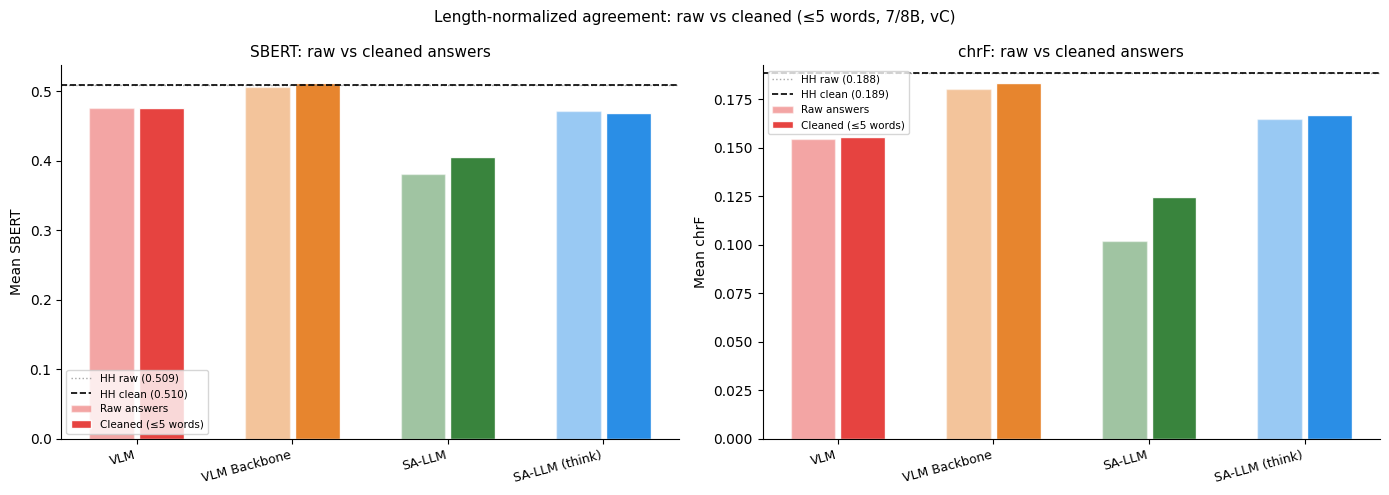

In [7]:
# Grouped bar: raw vs cleaned, SBERT and chrF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (rm, cm, mlabel) in zip(axes, [('sbert_score', 'sbert', 'SBERT'),
                                        ('chrf_score', 'chrf', 'chrF')]):
    x = np.arange(len(GROUP_ORDER))
    w = 0.32
    colors = [GROUP_COLORS.get(g, '#888') for g in GROUP_ORDER]

    raw_vals = [raw_grp.loc[g, rm] if g in raw_grp.index else 0 for g in GROUP_ORDER]
    cln_vals = [cln_grp.loc[g, cm] if g in cln_grp.index else 0 for g in GROUP_ORDER]

    ax.bar(x - w/2, raw_vals, w * 0.9, color=colors, alpha=0.45,
           edgecolor='white', label='Raw answers')
    ax.bar(x + w/2, cln_vals, w * 0.9, color=colors, alpha=0.95,
           edgecolor='white', label=f'Cleaned (≤{MAX_WORDS} words)')

    # HH ceilings
    ax.axhline(raw_hh[rm], color='grey', ls=':', lw=1, alpha=0.7, label=f'HH raw ({raw_hh[rm]:.3f})')
    ax.axhline(cln_hh[cm], color='black', ls='--', lw=1.2, label=f'HH clean ({cln_hh[cm]:.3f})')

    ax.set_xticks(x)
    ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone')
                        for g in GROUP_ORDER], fontsize=9, rotation=15, ha='right')
    ax.set_ylabel(f'Mean {mlabel}', fontsize=10)
    ax.set_title(f'{mlabel}: raw vs cleaned answers', fontsize=11)
    ax.legend(fontsize=7.5, frameon=True)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Length-normalized agreement: raw vs cleaned (≤{MAX_WORDS} words, 7/8B, vC)',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, f'raw_vs_cleaned_agreement_w{MAX_WORDS}')
plt.show()

## 5. All metrics side-by-side: cleaned

Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/length_bias/cleaned_all_metrics_groups_w5


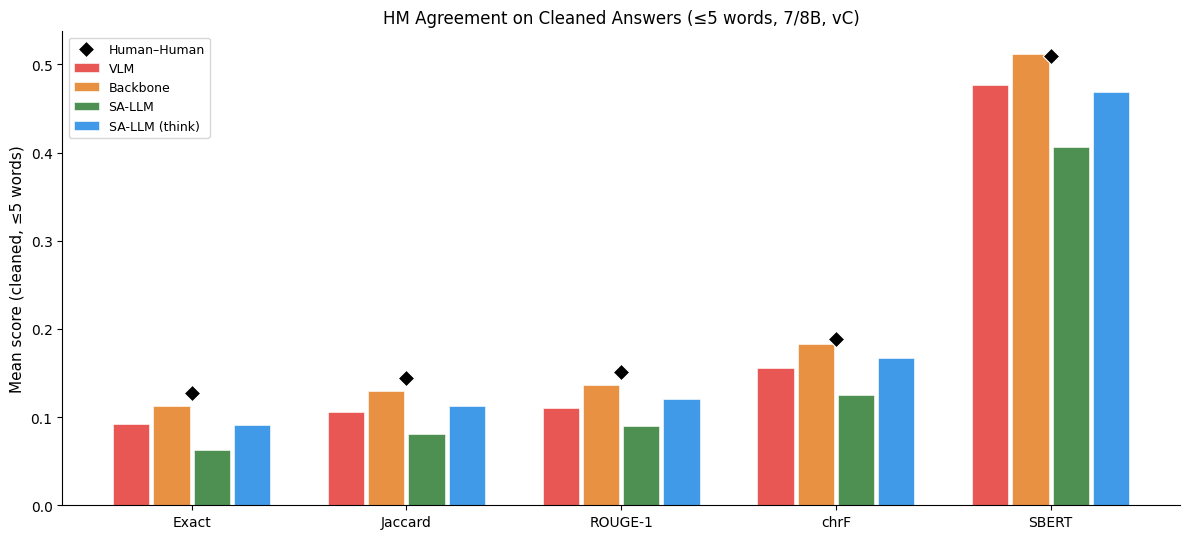

In [8]:
# Full metric comparison on cleaned answers — mirrors nb14 cell 11b
fig, ax = plt.subplots(figsize=(12, 5.5))

grp_order = ['VLM', 'VLM backbone decoder', 'standalone LLM', 'standalone LLM (think)']
grp_short = {
    'VLM': 'VLM', 'VLM backbone decoder': 'Backbone',
    'standalone LLM': 'SA-LLM', 'standalone LLM (think)': 'SA-LLM (think)',
}

n_metrics = len(CLN_METRICS)
n_groups = len(grp_order)
x = np.arange(n_metrics)
total_w = 0.75
w = total_w / n_groups

for gi, grp in enumerate(grp_order):
    if grp not in cln_grp.index:
        continue
    vals = cln_grp.loc[grp, CLN_METRICS].values
    offset = (gi - (n_groups - 1) / 2) * w
    color = GROUP_COLORS.get(grp, '#888')
    ax.bar(x + offset, vals, w * 0.9, color=color, alpha=0.85,
           label=grp_short[grp], edgecolor='white', linewidth=0.5)

# HH ceiling
ax.scatter(x, cln_hh[CLN_METRICS].values, marker='D', s=70, color='black',
           zorder=5, label='Human–Human', edgecolors='white', linewidths=0.8)

ax.set_xticks(x)
ax.set_xticklabels(METRIC_LABELS, fontsize=10)
ax.set_ylabel(f'Mean score (cleaned, ≤{MAX_WORDS} words)', fontsize=11)
ax.set_title(f'HM Agreement on Cleaned Answers (≤{MAX_WORDS} words, 7/8B, vC)', fontsize=12)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_fig(fig, OUT_DIR, f'cleaned_all_metrics_groups_w{MAX_WORDS}')
plt.show()

## 6. Summary

In [9]:
print(f'Length-normalized agreement summary (cleaned to ≤{MAX_WORDS} words)')
print('=' * 60)
print()
print('Group ranking by cleaned SBERT:')
sbert_rank = cln_grp['sbert'].sort_values(ascending=False)
for i, (grp, val) in enumerate(sbert_rank.items(), 1):
    raw_val = raw_grp.loc[grp, 'sbert_score']
    print(f'  {i}. {grp:<25s}  clean={val:.3f}  (raw={raw_val:.3f}, Δ={val-raw_val:+.3f})')
print(f'     {"HH ceiling":<25s}  clean={cln_hh["sbert"]:.3f}  (raw={raw_hh["sbert_score"]:.3f})')

print(f'\nKey finding: after stripping formatting and truncating to ≤{MAX_WORDS} words,')
print('does the group ranking change? Does SA-LLM close the gap to VLM?')
print()

# Token-level metrics (already length-robust) — did they change much?
print('Token-level metrics (already length-robust):')
for rm, cm, ml in zip(RAW_METRICS[:3], CLN_METRICS[:3], METRIC_LABELS[:3]):
    for grp in GROUP_ORDER:
        r = raw_grp.loc[grp, rm]
        c = cln_grp.loc[grp, cm]
        print(f'  {grp[:12]:<14s} {ml:<8}  raw={r:.3f}  clean={c:.3f}  Δ={c-r:+.3f}')

Length-normalized agreement summary (cleaned to ≤5 words)

Group ranking by cleaned SBERT:
  1. VLM backbone decoder       clean=0.512  (raw=0.506, Δ=+0.006)
  2. VLM                        clean=0.476  (raw=0.476, Δ=+0.001)
  3. standalone LLM (think)     clean=0.469  (raw=0.472, Δ=-0.003)
  4. standalone LLM             clean=0.406  (raw=0.381, Δ=+0.025)
     HH ceiling                 clean=0.510  (raw=0.509)

Key finding: after stripping formatting and truncating to ≤5 words,
does the group ranking change? Does SA-LLM close the gap to VLM?

Token-level metrics (already length-robust):
  VLM            Exact     raw=0.092  clean=0.092  Δ=+0.001
  VLM backbone   Exact     raw=0.110  clean=0.112  Δ=+0.002
  standalone L   Exact     raw=0.053  clean=0.063  Δ=+0.010
  standalone L   Exact     raw=0.091  clean=0.091  Δ=+0.000
  VLM            Jaccard   raw=0.105  clean=0.105  Δ=+0.001
  VLM backbone   Jaccard   raw=0.127  clean=0.129  Δ=+0.002
  standalone L   Jaccard   raw=0.069  clean=